In [6]:
from pathlib import Path
import json
from IPython.display import SVG, display
from synplan.utils.visualisation import get_route_svg_from_json

DATASET = "n5"

# Resolve project root whether the notebook is launched from repo root or tutorials/.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "PaRoutes" / "data" / f"{DATASET}-routes.json").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find the Retro-BLEU project root")

ROUTES_JSON_PATH = PROJECT_ROOT / "PaRoutes" / "data" / f"{DATASET}-routes.json"
ROUTES_WITHOUT_PATH = (
    PROJECT_ROOT
    / "composite_rules"
    / "comp_output"
    / DATASET
    / f"{DATASET}_routes_without_composite_rules.json"
)
SUMMARY_PATH = (
    PROJECT_ROOT
    / "composite_rules"
    / "comp_output"
    / DATASET
    / f"{DATASET}_composite_rule_extraction_summary.json"
)

with ROUTES_JSON_PATH.open() as f:
    routes_all = json.load(f)

with ROUTES_WITHOUT_PATH.open() as f:
    routes_without = json.load(f)

with SUMMARY_PATH.open() as f:
    extraction_summary = json.load(f)

len(routes_all), len(routes_without), extraction_summary


(10000,
 1791,
 {'routes_json': 'data/n5-routes.json',
  'routes_seen': 10000,
  'routes_with_composite_rules': 8209,
  'routes_without_composite_rules': 1791,
  'routes_without_composite_rules_file': 'comp_output/n5/n5_routes_without_composite_rules.json',
  'routes_without_composite_rules_by_reason': {'no_reaction_center_sharing_sequence': 1791},
  'reactions_seen': 38483,
  'reaction_rule_cache_hits': 48,
  'reaction_rule_cache_misses': 38435,
  'skipped_reactions': 0,
  'errors': 0,
  'unique_composite_rules': 12912,
  'raw_composite_rule_sequences': 16039,
  'target_molecule_occurrences': 18546,
  'min_length': 2,
  'max_length': 5,
  'output_prefix': 'comp_output/n5/n5',
  'output_files': {'2': 'comp_output/n5/n5_t2_composite_rules.tsv',
   '3': 'comp_output/n5/n5_t3_composite_rules.tsv',
   '4': 'comp_output/n5/n5_t4_composite_rules.tsv',
   '5': 'comp_output/n5/n5_t5_composite_rules.tsv'},
  'unique_composite_rules_by_size': {'2': 8916, '3': 3076, '4': 766, '5': 154},
  'summar

In [7]:
route_ids = list(routes_without.keys())
route_ids

['83',
 '92',
 '110',
 '252',
 '253',
 '283',
 '294',
 '341',
 '426',
 '461',
 '493',
 '522',
 '523',
 '575',
 '598',
 '616',
 '621',
 '638',
 '639',
 '646',
 '649',
 '650',
 '652',
 '653',
 '672',
 '673',
 '680',
 '703',
 '729',
 '752',
 '776',
 '782',
 '813',
 '862',
 '868',
 '895',
 '919',
 '937',
 '938',
 '939',
 '943',
 '944',
 '952',
 '996',
 '997',
 '1004',
 '1013',
 '1014',
 '1066',
 '1078',
 '1090',
 '1101',
 '1102',
 '1111',
 '1121',
 '1124',
 '1139',
 '1143',
 '1145',
 '1166',
 '1175',
 '1189',
 '1222',
 '1233',
 '1253',
 '1267',
 '1271',
 '1289',
 '1304',
 '1317',
 '1318',
 '1357',
 '1367',
 '1377',
 '1416',
 '1425',
 '1427',
 '1448',
 '1453',
 '1454',
 '1456',
 '1478',
 '1490',
 '1498',
 '1515',
 '1522',
 '1523',
 '1524',
 '1530',
 '1547',
 '1553',
 '1565',
 '1569',
 '1580',
 '1588',
 '1603',
 '1612',
 '1619',
 '1625',
 '1641',
 '1651',
 '1668',
 '1725',
 '1735',
 '1738',
 '1758',
 '1782',
 '1786',
 '1798',
 '1802',
 '1816',
 '1861',
 '1869',
 '1873',
 '1889',
 '1904',
 '1

In [8]:
# route_id = next(iter(routes_without))
# route_id = '83'
for route_id in route_ids[:20]:
    print(route_id)
    svg = get_route_svg_from_json(routes_without, route_id, labeled=True)
    display(SVG(svg))


83


92


110


252


253


283


294


341


426


461


493


522


523


575


598


616


621


638


639


646


In [9]:
from collections import Counter
import matplotlib.pyplot as plt


def iter_routes(routes_json):
    if isinstance(routes_json, list):
        yield from enumerate(routes_json)
    else:
        yield from routes_json.items()


def count_reactions(route):
    count = 0

    def visit(node):
        nonlocal count
        if not isinstance(node, dict):
            return
        if node.get("type") == "reaction":
            count += 1
        for child in node.get("children", []) or []:
            visit(child)

    visit(route)
    return count


routes_without_ids = {str(route_id) for route_id in routes_without}
route_status_rows = []

for route_id, route in iter_routes(routes_all):
    route_id = str(route_id)
    status = "routes_without" if route_id in routes_without_ids else "routes_with"
    route_status_rows.append(
        {
            "route_id": route_id,
            "reactions_seen": count_reactions(route),
            "status": status,
        }
    )

hist_counts = {
    status: Counter(
        row["reactions_seen"] for row in route_status_rows if row["status"] == status
    )
    for status in ["routes_with", "routes_without"]
}

x_values = sorted({row["reactions_seen"] for row in route_status_rows})
routes_with_counts = [hist_counts["routes_with"].get(x, 0) for x in x_values]
routes_without_counts = [hist_counts["routes_without"].get(x, 0) for x in x_values]

print("routes_with:", sum(routes_with_counts))
print("routes_without:", sum(routes_without_counts))
print("summary routes_with:", extraction_summary.get("routes_with_composite_rules"))
print("summary routes_without:", extraction_summary.get("routes_without_composite_rules"))
print("without reasons:", extraction_summary.get("routes_without_composite_rules_by_reason"))


routes_with: 8209
routes_without: 1791
summary routes_with: 8209
summary routes_without: 1791
without reasons: {'no_reaction_center_sharing_sequence': 1791}


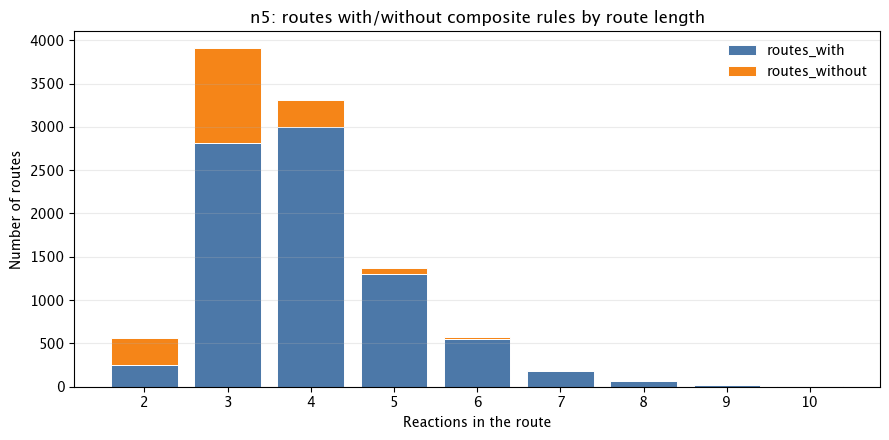

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    x_values,
    routes_with_counts,
    label="routes_with",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.7,
)
ax.bar(
    x_values,
    routes_without_counts,
    bottom=routes_with_counts,
    label="routes_without",
    color="#F58518",
    edgecolor="white",
    linewidth=0.7,
)

ax.set_xlabel("Reactions in the route")
ax.set_ylabel("Number of routes")
ax.set_title(f"{DATASET}: routes with/without composite rules by route length")
ax.set_xticks(x_values)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [30]:
x = 0
for route_id, route in routes_without.items():
    if route['metadata']['composite_rule_extraction']["reactions_seen"] == 9:
        print(route_id)
    
    if route['metadata']['composite_rule_extraction']["reactions_seen"] == 6:
        print(route_id)
        svg = get_route_svg_from_json(routes_without, route_id, labeled=True)
        display(SVG(svg))
    
        x += 1

    if x == 10:
        break

60


149


234


403


2249


7467
